# Yiled Curve


In [ ]:
!pip install bcchapi

In [ ]:
import bcchapi
import numpy as np
import pandas as pd
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

In [ ]:
excel_url = "https://si3.bcentral.cl/estadisticas/Principal1/Web_Services/Webservices/series.xlsx"

In [ ]:
json.dump(
    pd.read_excel(excel_url)
      .loc[lambda d: d["NOMBRE CUADRO"] == "Tasas swap promedio cámara (SPC)",
           ["NOMBRE DE LA SERIE","CÓDIGO"]]
      .drop_duplicates("CÓDIGO")
      .set_index("NOMBRE DE LA SERIE")["CÓDIGO"]
      .to_dict(),
    open("series_spc.json","w",encoding="utf-8"),
    ensure_ascii=False,
    indent=2
)

In [ ]:
imacec: F032.IMC.IND.Z.Z.EP18.Z.Z.1.M
inflacion : F074.IPC.IND.Z.EP09.C.M


In [ ]:
def get_bcch_curve(json_path,
                   desde="2010-01-01",
                   hasta="2026-03-31",
                   workers=20):

    series_dict = json.load(open(json_path, encoding="utf-8"))

    def download_one(item):
        name, code = item
        return siete.cuadro(
            series=[code],
            nombres=[name],
            desde=desde,
            hasta=hasta
        )

    with ThreadPoolExecutor(max_workers=workers) as executor:
        dfs = list(executor.map(download_one, series_dict.items()))

    return pd.concat(dfs, axis=1)

In [ ]:
df_swap = get_bcch_curve("series_spc.json")

In [ ]:
df_yields = df_swap.iloc[:, :5]

Columnas usadas:
Index(['SPC en pesos 2 años', 'SPC en pesos 3 años', 'SPC en pesos 4 años',
       'SPC en pesos 5 años', 'SPC en pesos 10 años'],
      dtype='object')
Shape X: (5, 3)

Factores Nelson-Siegel:
                level      slope   curvature
2010-01-04 -92.850685  93.559824  141.103856
2010-01-05 -90.123795  90.959136  137.355235
2010-01-06 -87.208811  88.128311  133.483335
2010-01-07 -85.240137  86.267477  130.733414
2010-01-08 -87.248366  88.160400  133.513965


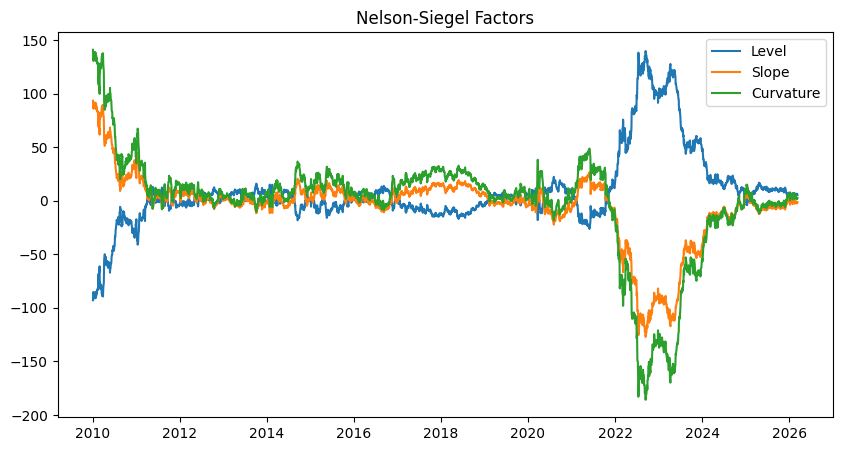


Curva estimada última fecha:
[4.64360256 4.74636056 4.84219373 4.93153627 5.29431592]


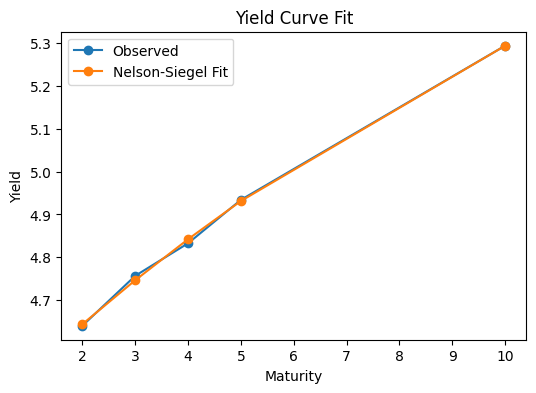

In [ ]:
# ======================================================
# 1. SELECCIONAR COLUMNAS DE TASAS
# ======================================================

# tomar primeras 5 columnas (2y 3y 4y 5y 10y)
df_yields = df_swap.iloc[:, :5].copy()

# asegurar que todo sea numérico
df_yields = df_yields.apply(pd.to_numeric, errors="coerce")

# eliminar filas con NaN
df_yields = df_yields.dropna()

print("Columnas usadas:")
print(df_yields.columns)


# ======================================================
# 2. MATURITIES
# ======================================================

tau = np.array([2,3,4,5,10])


# ======================================================
# 3. FUNCIÓN NELSON-SIEGEL LOADINGS
# ======================================================

def nelson_siegel_loadings(tau, lam):

    level = np.ones(len(tau))

    slope = (1 - np.exp(-lam * tau)) / (lam * tau)

    curvature = slope - np.exp(-lam * tau)

    return np.column_stack([level, slope, curvature])


# ======================================================
# 4. PARÁMETRO LAMBDA
# ======================================================

lam = 0.0609


# ======================================================
# 5. MATRIZ DE LOADINGS
# ======================================================

X = nelson_siegel_loadings(tau, lam)

print("Shape X:", X.shape)


# ======================================================
# 6. ESTIMAR FACTORES NELSON-SIEGEL
# ======================================================

betas = []

for date, row in df_yields.iterrows():

    y = row.to_numpy(dtype=float)

    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    betas.append(beta)


# ======================================================
# 7. DATAFRAME FACTORES
# ======================================================

betas = pd.DataFrame(
    betas,
    index=df_yields.index,
    columns=["level", "slope", "curvature"]
)

print("\nFactores Nelson-Siegel:")
print(betas.head())


# ======================================================
# 8. GRAFICAR FACTORES
# ======================================================

plt.figure(figsize=(10,5))

plt.plot(betas.index, betas["level"], label="Level")
plt.plot(betas.index, betas["slope"], label="Slope")
plt.plot(betas.index, betas["curvature"], label="Curvature")

plt.title("Nelson-Siegel Factors")
plt.legend()
plt.show()


# ======================================================
# 9. RECONSTRUIR CURVA (CHECK)
# ======================================================

last_beta = betas.iloc[-1].values

y_hat = X @ last_beta

print("\nCurva estimada última fecha:")
print(y_hat)


# ======================================================
# 10. COMPARAR CURVA REAL VS AJUSTADA
# ======================================================

plt.figure(figsize=(6,4))

plt.plot(tau, df_yields.iloc[-1].values, "o-", label="Observed")
plt.plot(tau, y_hat, "o-", label="Nelson-Siegel Fit")

plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.legend()

plt.title("Yield Curve Fit")

plt.show()

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

# X = variables macro
X = df[['inflation','gdp','unemployment','policy_rate']]

# y = factores Nelson Siegel
y = df[['beta1','beta2','beta3']]

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

model.fit(X,y)

# obtener hojas del árbol
leaf_nodes = model.apply(X)

# clusterizar hojas -> regímenes
kmeans = KMeans(n_clusters=4)

df["regime"] = kmeans.fit_predict(leaf_nodes)